<a href="https://colab.research.google.com/github/AichaELMouta/GiveMeSomeCreditClassification/blob/main/CreditClassificationML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
creditdata = pd.read_csv('cs-training.csv')

In [5]:
creditdata.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0


In [6]:
creditdata.columns


Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

Understanding Columns:
1.  SeriousDlqin2yrs
2.  RevolvingUtilizationOfUnsecuredLines
1.  age
2.  NumberOfTime30-59DaysPastDueNotWorse
1.  DebtRatio
2.  MonthlyIncome
1.  NumberOfOpenCreditLinesAndLoans
2.  NumberOfTimes90DaysLate
1.  NumberRealEstateLoansOrLines
2.  NumberOfTime60-89DaysPastDueNotWorse
1.  NumberOfDependents


















In [7]:
creditdata.shape

(125113, 12)

In [8]:
creditdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125113 entries, 0 to 125112
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            125113 non-null  int64  
 1   SeriousDlqin2yrs                      125113 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  125113 non-null  float64
 3   age                                   125113 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  125113 non-null  int64  
 5   DebtRatio                             125113 non-null  float64
 6   MonthlyIncome                         100310 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       125112 non-null  float64
 8   NumberOfTimes90DaysLate               125112 non-null  float64
 9   NumberRealEstateLoansOrLines          125112 non-null  float64
 10  NumberOfTime60-89DaysPastDueNotWorse  125112 non-null  float64
 11  

In [9]:
creditdata[creditdata.duplicated(keep=False)]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


In [10]:
creditdata.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,24803
NumberOfOpenCreditLinesAndLoans,1
NumberOfTimes90DaysLate,1
NumberRealEstateLoansOrLines,1


In [11]:
null_rows = creditdata[creditdata['MonthlyIncome'].isna()]
null_rows

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
6,7,0,0.305682,57,0,5710.0,NaN,8.0,0.0,3.0,0.0,0.0
8,9,0,0.116951,27,0,46.0,NaN,2.0,0.0,0.0,0.0,NaN
16,17,0,0.061086,78,0,2058.0,NaN,10.0,0.0,2.0,0.0,0.0
32,33,0,0.083418,62,0,977.0,NaN,6.0,0.0,1.0,0.0,0.0
41,42,0,0.072898,81,0,75.0,NaN,7.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
125095,125096,0,0.091441,58,0,107.0,NaN,2.0,0.0,0.0,0.0,0.0
125096,125097,0,0.726898,38,0,4675.0,NaN,12.0,0.0,2.0,0.0,3.0
125098,125099,1,1.028662,76,2,1867.0,NaN,6.0,1.0,3.0,0.0,0.0
125108,125109,0,0.000000,76,0,0.0,NaN,4.0,0.0,0.0,0.0,0.0


In [12]:
null_rows_dependent = creditdata[creditdata['NumberOfDependents'].isna()]
null_rows_dependent

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8,9,0,0.116951,27,0,46.0,NaN,2.0,0.0,0.0,0.0,NaN
96,97,0,0.542243,48,2,10.0,NaN,2.0,0.0,0.0,0.0,NaN
109,110,0,0.041258,61,0,4739.0,NaN,11.0,0.0,4.0,0.0,NaN
159,160,0,0.000000,63,0,2.0,NaN,4.0,0.0,0.0,0.0,NaN
238,239,0,1.000000,28,0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
124946,124947,0,0.121646,48,0,1262.0,NaN,7.0,0.0,1.0,0.0,NaN
124991,124992,0,0.070964,63,0,1198.0,NaN,7.0,0.0,2.0,0.0,NaN
125005,125006,0,0.706698,57,1,2238.0,NaN,8.0,0.0,1.0,0.0,NaN
125028,125029,0,0.346723,55,1,2205.0,NaN,21.0,0.0,1.0,0.0,NaN


In [13]:
creditdata['SeriousDlqin2yrs'].value_counts()

,count
SeriousDlqin2yrs,
0,116810
1,8303


In [14]:
creditdata['SeriousDlqin2yrs'].value_counts(normalize=True)

,proportion
SeriousDlqin2yrs,
0,0.933636
1,0.066364


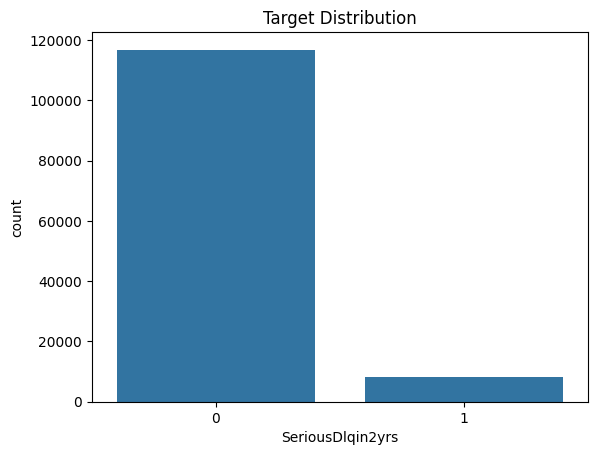

In [15]:
sns.countplot(x='SeriousDlqin2yrs', data=creditdata)
plt.title("Target Distribution")
plt.show()

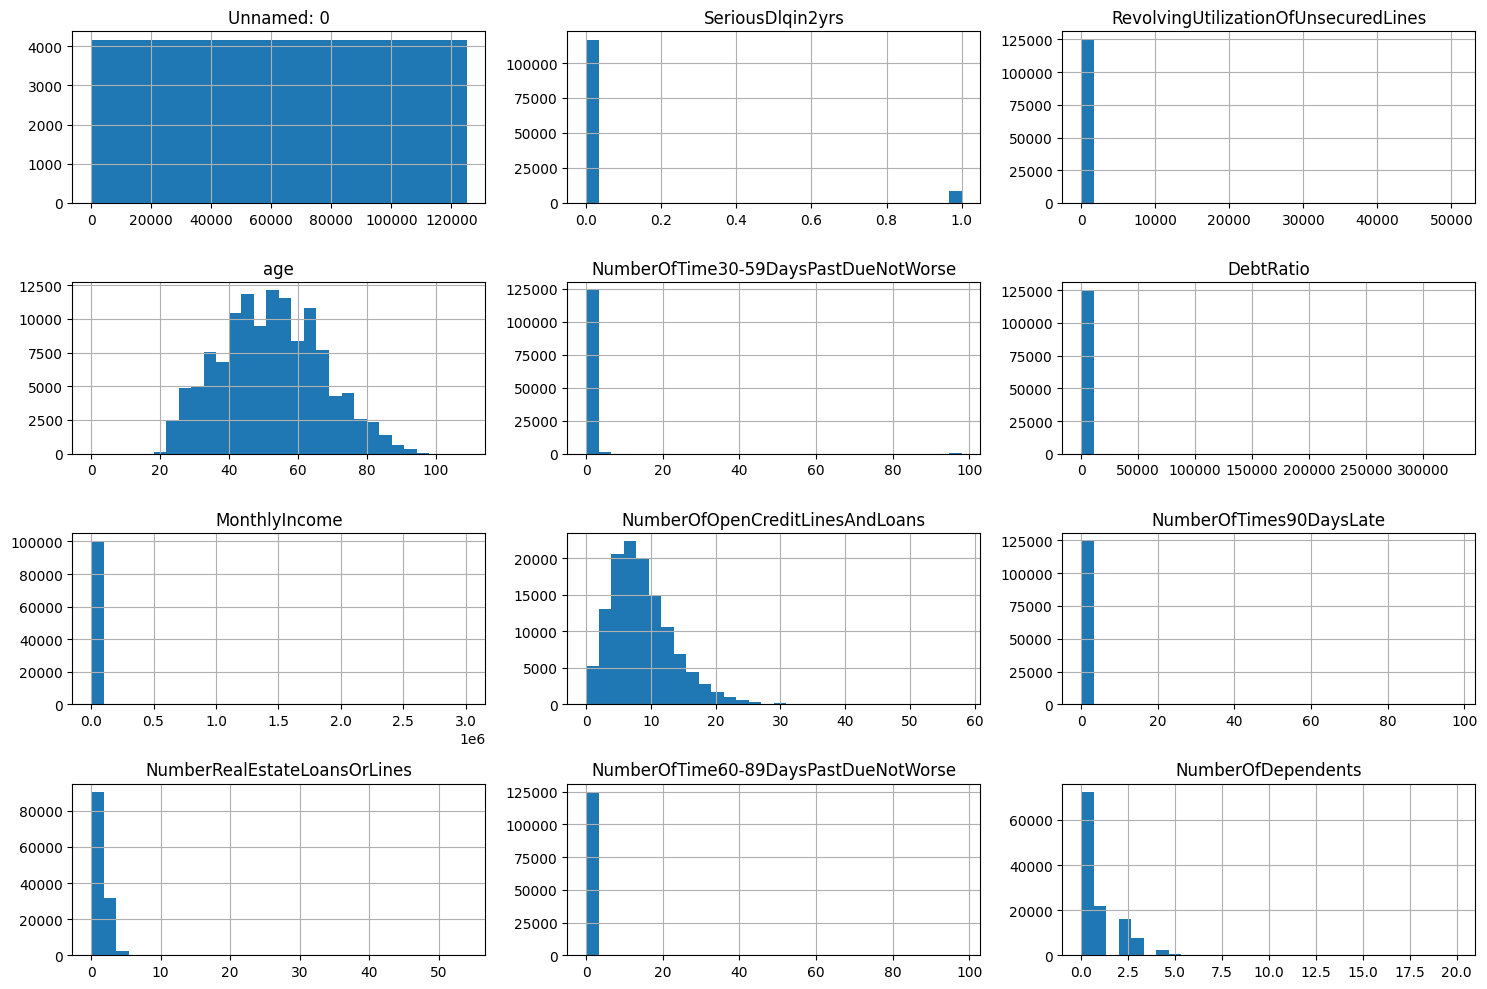

In [16]:
creditdata.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

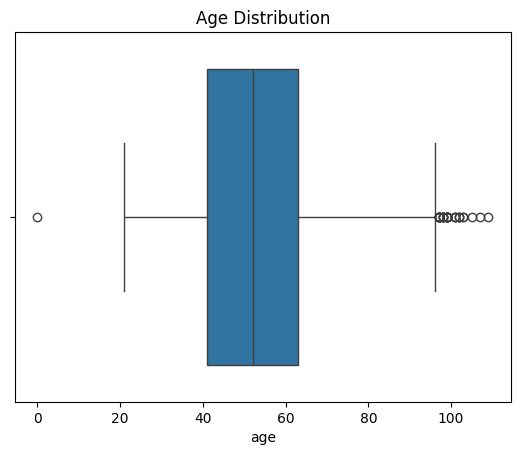

In [17]:
sns.boxplot(x=creditdata['age'])
plt.title("Age Distribution")
plt.show()

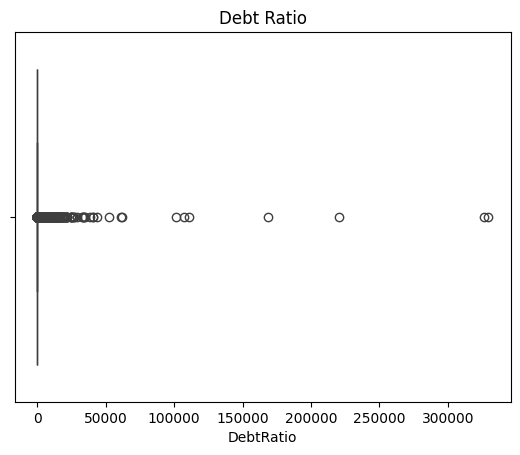

In [18]:
sns.boxplot(x=creditdata['DebtRatio'])
plt.title("Debt Ratio")
plt.show()

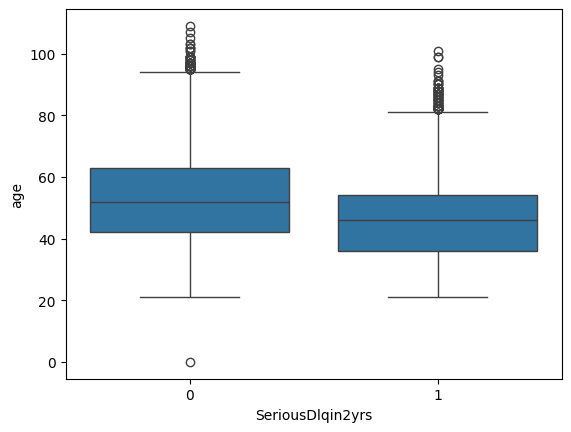

In [19]:
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=creditdata)
plt.show()

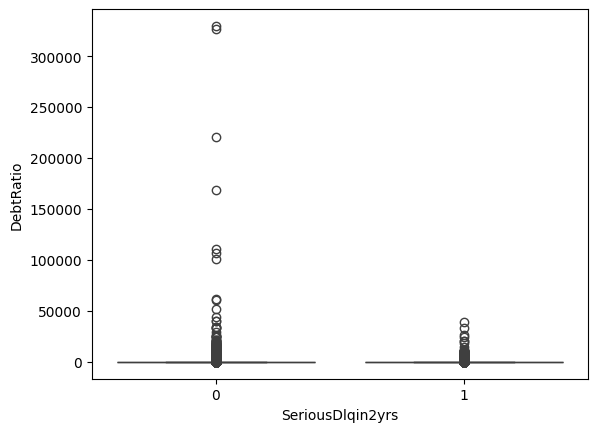

In [20]:
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', data=creditdata)
plt.show()

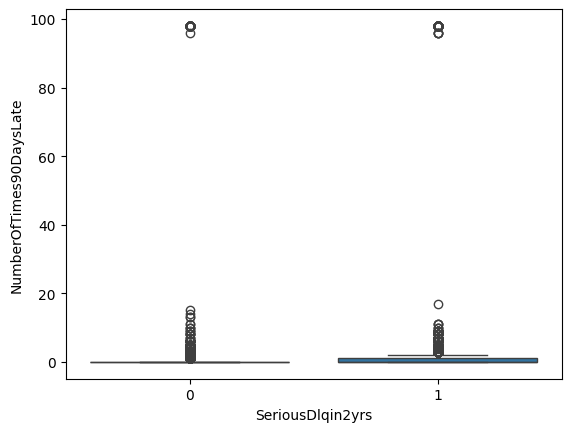

In [21]:
sns.boxplot(x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate', data=creditdata)
plt.show()

Statistical Tests

In [51]:
from scipy.stats import ttest_ind
stat, p = ttest_ind(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['age'], creditdata[creditdata['SeriousDlqin2yrs'] == 1]['age'])
print(f"T-statistic: {stat}")
print(f"P-value: {p}")

T-statistic: 40.93960242251573
P-value: 0.0


In [52]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['DebtRatio'],creditdata[creditdata['SeriousDlqin2yrs'] == 1]['DebtRatio'])

print("p-value:", p_value)

p-value: 5.645079775265927e-12


In [53]:
stat, p_value = mannwhitneyu(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['MonthlyIncome'],creditdata[creditdata['SeriousDlqin2yrs'] == 1]['MonthlyIncome'])

print("p-value:", p_value)

p-value: 2.0524198583378012e-25


In [55]:
stat, p_value = mannwhitneyu(creditdata[creditdata['SeriousDlqin2yrs'] == 0]['RevolvingUtilizationOfUnsecuredLines'],creditdata[creditdata['SeriousDlqin2yrs'] == 1]['RevolvingUtilizationOfUnsecuredLines'])

print("p-value:", p_value)

p-value: 0.0


In [59]:
creditdata.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing', 'age_bin'],
      dtype='object')

In [60]:
creditdata.drop(columns=['age_bin'], inplace=True)

In [61]:
creditdata.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)

,SeriousDlqin2yrs
SeriousDlqin2yrs,1.000000
NumberOfTime30-59DaysPastDueNotWorse,0.123088
NumberOfTimes90DaysLate,0.114530
NumberOfTime60-89DaysPastDueNotWorse,0.099646
NumberOfDependents,0.045183
RevolvingUtilizationOfUnsecuredLines,-0.002882
NumberRealEstateLoansOrLines,-0.006767
DebtRatio,-0.007325
NumberOfDependents_missing,-0.012906
MonthlyIncome,-0.013847


In [62]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(creditdata['NumberOfDependents'], creditdata['SeriousDlqin2yrs'])
chi2, p, _, _ = chi2_contingency(contingency)

print("p-value:", p)

p-value: 6.692587242056614e-51


In [22]:
creditdata.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,125113.000000,125113.000000,125113.000000,125113.000000,125113.000000,125113.000000,1.003100e+05,125112.000000,125112.000000,125112.00000,125112.000000,121841.000000
mean,62557.000000,0.066364,6.051709,52.280842,0.419932,353.682980,6.681452e+03,8.455256,0.265570,1.02007,0.239561,0.756108
std,36117.156452,0.248918,250.665369,14.758723,4.188639,1985.456257,1.436905e+04,5.142700,4.164854,1.13713,4.151457,1.112236
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000
25%,31279.000000,0.000000,0.030022,41.000000,0.000000,0.175066,3.400000e+03,5.000000,0.000000,0.00000,0.000000,0.000000
50%,62557.000000,0.000000,0.155435,52.000000,0.000000,0.367106,5.400000e+03,8.000000,0.000000,1.00000,0.000000,0.000000
75%,93835.000000,0.000000,0.560315,63.000000,0.000000,0.870017,8.250000e+03,11.000000,0.000000,2.00000,0.000000,1.000000
max,125113.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.00000,98.000000,20.000000


In [23]:
creditdata['MonthlyIncome_missing'] = creditdata['MonthlyIncome'].isnull().astype(int)

In [24]:
creditdata['MonthlyIncome_missing'].head()

,MonthlyIncome_missing
0,0
1,0
2,0
3,0
4,0


In [25]:
creditdata[creditdata['NumberOfDependents'].isna()]


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
8,9,0,0.116951,27,0,46.0,NaN,2.0,0.0,0.0,0.0,NaN,1
96,97,0,0.542243,48,2,10.0,NaN,2.0,0.0,0.0,0.0,NaN,1
109,110,0,0.041258,61,0,4739.0,NaN,11.0,0.0,4.0,0.0,NaN,1
159,160,0,0.000000,63,0,2.0,NaN,4.0,0.0,0.0,0.0,NaN,1
238,239,0,1.000000,28,0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
124946,124947,0,0.121646,48,0,1262.0,NaN,7.0,0.0,1.0,0.0,NaN,1
124991,124992,0,0.070964,63,0,1198.0,NaN,7.0,0.0,2.0,0.0,NaN,1
125005,125006,0,0.706698,57,1,2238.0,NaN,8.0,0.0,1.0,0.0,NaN,1
125028,125029,0,0.346723,55,1,2205.0,NaN,21.0,0.0,1.0,0.0,NaN,1


In [26]:
creditdata.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
MonthlyIncome_missing,
0,0.069006
1,0.055679


<Axes: xlabel='MonthlyIncome_missing', ylabel='DebtRatio'>

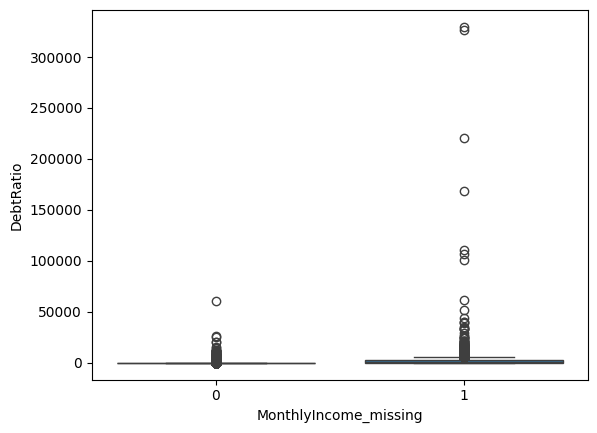

In [27]:
import seaborn as sns
sns.boxplot(x='MonthlyIncome_missing', y='DebtRatio', data=creditdata)

In [28]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(creditdata['MonthlyIncome_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 56.79133287893089
P-value: 4.845974940316784e-14


p_value << 0.05 that means there is statistically significant relationship between missing income and default risk.

In [29]:
creditdata['NumberOfDependents'].value_counts()

,count
NumberOfDependents,
0.0,72458
1.0,22013
2.0,16307
3.0,7880
4.0,2371
5.0,616
6.0,129
7.0,41
8.0,17


In [30]:
creditdata['NumberOfDependents_missing'] = creditdata['NumberOfDependents'].isnull().astype(int)

In [31]:
creditdata.groupby('NumberOfDependents_missing')['SeriousDlqin2yrs'].mean()

,SeriousDlqin2yrs
NumberOfDependents_missing,
0,0.06689
1,0.04676


In [32]:
contingency_table = pd.crosstab(creditdata['NumberOfDependents_missing'], creditdata['SeriousDlqin2yrs'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p}")

Chi-squared statistic: 20.515740984950156
P-value: 5.914287412015023e-06


The chi-square test shows a statistically significant association between missing values in NumberOfDependents and SeriousDlqin2yrs (p < 0.05). Applicants with missing dependents have a lower observed default rate, suggesting that missingness carries predictive information.

In [33]:
print('Skewness coeficient',creditdata['age'].skew())

Skewness coeficient 0.18612511358814574


In [34]:
if "Unnamed: 0" in creditdata.columns:
    creditdata = creditdata.drop(columns=["Unnamed: 0"])

In [35]:
creditdata.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
0,1,0.766127,45,2,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0,0,0
1,0,0.957151,40,0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0,0,0
2,0,0.658180,38,1,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0,0,0
3,0,0.233810,30,0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0,0,0


EDA

In [36]:
creditdata.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing',
       'NumberOfDependents_missing'],
      dtype='object')

In [37]:
import plotly.express as px
px.histogram(creditdata , x = 'age' ,  text_auto = '.1f' , title = 'age Range')

In [38]:
px.histogram(creditdata , x = 'MonthlyIncome' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [39]:
px.histogram(creditdata , x = 'NumberRealEstateLoansOrLines' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [40]:
px.histogram(creditdata , x = 'SeriousDlqin2yrs' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [41]:
px.histogram(creditdata , x = 'NumberOfTime30-59DaysPastDueNotWorse' ,  text_auto = '.1f' , title = 'Monthly Income Range')

In [42]:
creditdata["age_bin"] = pd.cut(creditdata["age"], bins=[20,30,40,50,60,70,100])

creditdata.groupby("age_bin")["SeriousDlqin2yrs"].mean()



/tmp/ipykernel_16960/1677721344.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,SeriousDlqin2yrs
age_bin,
"(20, 30]",0.116240
"(30, 40]",0.096674
"(40, 50]",0.082565
"(50, 60]",0.060848
"(60, 70]",0.034156
"(70, 100]",0.022741


In [43]:
y = creditdata['SeriousDlqin2yrs']
X = creditdata.drop(columns = ['SeriousDlqin2yrs'])

This project compares various classification algorithms to identify the most effective model for predicting customer creditworthiness and minimizing default risk.

In [44]:
from sklearn.ensemble import RandomForestRegressor

features_for_impute = [
    'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents', 'RevolvingUtilizationOfUnsecuredLines'
]
train_income = creditdata[creditdata['MonthlyIncome'].notna()]
test_income = creditdata[creditdata['MonthlyIncome'].isna()]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_income[features_for_impute], train_income['MonthlyIncome'])

predicted_income = rf.predict(test_income[features_for_impute])

creditdata.loc[creditdata['MonthlyIncome'].isnull(), 'MonthlyIncome'] = predicted_income

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

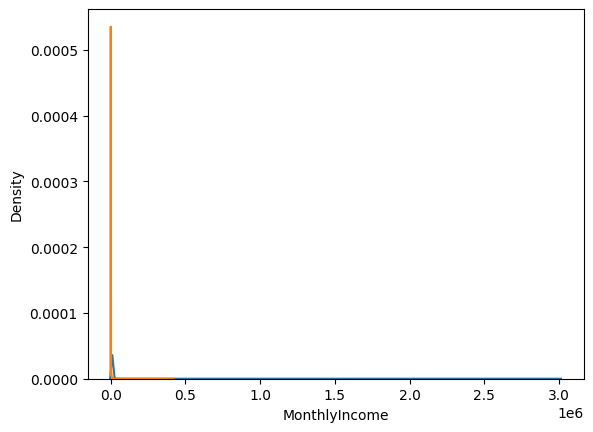

In [45]:
# Compare distributions
sns.kdeplot(train_income['MonthlyIncome'], label='Original')
sns.kdeplot(predicted_income, label='Imputed')

I used Random Forest for imputing MonthlyIncome because it captures non-linear relationships between financial features, is robust to outliers, and requires minimal preprocessing. Since the goal was to generate realistic values rather than perfectly predict income, it provided a strong and stable solution.

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

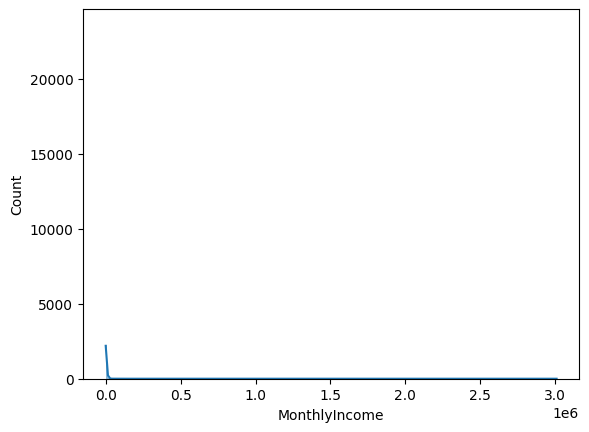

In [46]:
sns.histplot(creditdata['MonthlyIncome'], kde=True)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



<Axes: xlabel='MonthlyIncome', ylabel='Count'>

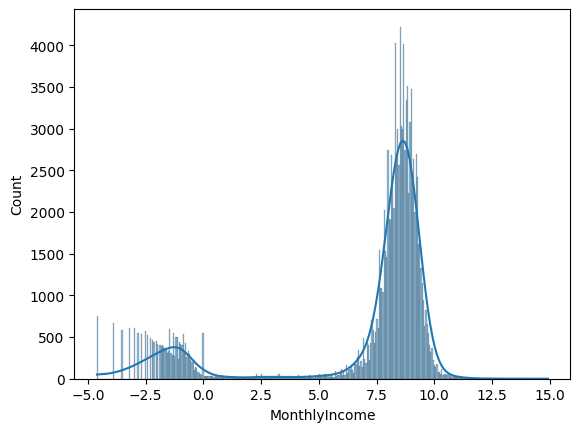

In [47]:
sns.histplot(np.log(creditdata['MonthlyIncome']), kde=True)

In [48]:
creditdata['MonthlyIncome'].skew()

np.float64(119.47553461268718)

In [49]:
np.log1p(creditdata['MonthlyIncome']).skew()

np.float64(-1.4896609004482404)